# Text & Cross-Modal Analysis — UA-SER

This notebook validates the ground-truth emotion labels using two independent signals:
1. **VAD prediction** — `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim` on raw audio
2. **LLM classification** — Claude Sonnet 4.6 zero-shot on transcripts

Outputs saved: `vad_results.csv`, `text_emotion_llm_results.csv`

In [1]:
import os, json, time, re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

ANALYSIS_DIR = Path('.')
BASE_DIR     = ANALYSIS_DIR.parent
DATASET_CSV  = BASE_DIR / 'dataset.csv'
CLIPS_DIR    = BASE_DIR / 'clips'
FIGURES_DIR  = ANALYSIS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

EMOTION_ORDER  = ['angry', 'happy', 'neutral', 'sad']
EMOTION_COLORS = {'angry': '#e74c3c', 'happy': '#f39c12', 'neutral': '#3498db', 'sad': '#8e44ad'}
PALETTE = [EMOTION_COLORS[e] for e in EMOTION_ORDER]

sns.set_theme(style='whitegrid', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'axes.titlesize': 14, 'axes.labelsize': 12,
})

def save(fig, name):
    fig.savefig(FIGURES_DIR / f'{name}.png', bbox_inches='tight')
    fig.savefig(FIGURES_DIR / f'{name}.pdf', bbox_inches='tight')
    plt.close(fig)
    print(f'  saved {name}.png / .pdf')

## 1. Load Dataset

In [3]:
df = pd.read_csv(DATASET_CSV)
df['gender']     = df['filename'].str.extract(r'_(\d)\.wav$')[0].astype(int).map({0: 'male', 1: 'female'})
df['word_count'] = df['text'].fillna('').apply(lambda t: len(t.split()))

print(f'Loaded {len(df)} samples  |  {df["emotion"].nunique()} classes  |  {df["gender"].nunique()} genders')
display(df['emotion'].value_counts().reindex(EMOTION_ORDER).rename('count').to_frame())

Loaded 952 samples  |  4 classes  |  2 genders


,count
emotion,
angry,259
happy,244
neutral,222
sad,227


## 2. VAD Prediction

Valence, Arousal, Dominance scores predicted from raw audio using `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim`. Results cached to `vad_results.csv`.

In [5]:
VAD_CSV = ANALYSIS_DIR / 'vad_results.csv'

if VAD_CSV.exists():
    print(f'Loading cached VAD results: {VAD_CSV}')
    vad_df = pd.read_csv(VAD_CSV)
else:
    import torch
    import torch.nn as nn
    import librosa
    from tqdm import tqdm
    from transformers import Wav2Vec2Processor
    from transformers.models.wav2vec2.modeling_wav2vec2 import Wav2Vec2Model, Wav2Vec2PreTrainedModel

    MODEL_NAME = 'audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim'

    class RegressionHead(nn.Module):
        def __init__(self, config):
            super().__init__()
            self.dense    = nn.Linear(config.hidden_size, config.hidden_size)
            self.dropout  = nn.Dropout(config.final_dropout)
            self.out_proj = nn.Linear(config.hidden_size, config.num_labels)
        def forward(self, features, **kwargs):
            x = self.dropout(features)
            x = torch.tanh(self.dense(x))
            x = self.dropout(x)
            return self.out_proj(x)

    class EmotionModel(Wav2Vec2PreTrainedModel):
        def __init__(self, config):
            super().__init__(config)
            self.wav2vec2   = Wav2Vec2Model(config)
            self.classifier = RegressionHead(config)
            self.init_weights()
        def forward(self, input_values):
            hidden = self.wav2vec2(input_values)[0]
            hidden = torch.mean(hidden, dim=1)
            return hidden, self.classifier(hidden)

    print(f'Loading {MODEL_NAME} ...')
    processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
    model     = EmotionModel.from_pretrained(MODEL_NAME)
    model.eval()

    results, missing = [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='VAD'):
        wav_path = CLIPS_DIR / row['filename']
        if not wav_path.exists():
            missing.append(row['filename'])
            results.append({'filename': row['filename'],
                            'arousal': np.nan, 'dominance': np.nan, 'valence': np.nan})
            continue
        y, _ = librosa.load(str(wav_path), sr=16000, mono=True)
        inp   = processor(y, sampling_rate=16000)
        iv    = torch.from_numpy(inp['input_values'][0].reshape(1, -1))
        with torch.no_grad():
            _, logits = model(iv)
        s = logits.squeeze().numpy()
        results.append({'filename': row['filename'],
                        'arousal': float(s[0]), 'dominance': float(s[1]), 'valence': float(s[2])})

    if missing:
        print(f'WARNING: {len(missing)} files not found')
    vad_raw = pd.DataFrame(results)
    vad_df  = df[['filename', 'emotion']].merge(vad_raw, on='filename')
    vad_df.to_csv(VAD_CSV, index=False)
    print(f'Saved {VAD_CSV}')

Loading cached VAD results: vad_results.csv


In [6]:
# ── Descriptive statistics per emotion ──────────────────────────────────────
print('=== VAD Descriptive Statistics per Emotion ===\n')
for dim in ['valence', 'arousal', 'dominance']:
    grp = vad_df.groupby('emotion')[dim].agg(
        ['mean', 'std', 'median',
         lambda x: x.quantile(.25), lambda x: x.quantile(.75)]
    ).reindex(EMOTION_ORDER)
    grp.columns = ['Mean', 'Std', 'Median', 'Q1', 'Q3']
    print(f'  {dim.upper()}')
    display(grp.round(3))
    print()

# ── Kruskal-Wallis tests ─────────────────────────────────────────────────────
k_grp = len(EMOTION_ORDER)
n_vad = len(vad_df.dropna(subset=['valence']))

print('=== Kruskal-Wallis Tests on VAD Dimensions ===\n')
print(f'  {"Dimension":<13} {"H":>8} {"p-value":>10} {"\u03b5\u00b2":>8}  sig')
print('  ' + '-' * 50)
vad_kw = {}
for dim in ['valence', 'arousal', 'dominance']:
    grps = [vad_df[vad_df['emotion'] == e][dim].dropna().values for e in EMOTION_ORDER]
    H, p = stats.kruskal(*grps)
    eps2 = (H - k_grp + 1) / (n_vad - k_grp)
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    vad_kw[dim] = {'H': H, 'p': p, 'eps2': eps2}
    print(f'  {dim:<13} {H:>8.3f} {p:>10.4f} {eps2:>8.4f}  {sig}')
print('\n  *** p<0.001  ** p<0.01  * p<0.05')

=== VAD Descriptive Statistics per Emotion ===

  VALENCE


,Mean,Std,Median,Q1,Q3
emotion,,,,,
angry,0.430,0.144,0.443,0.339,0.516
happy,0.594,0.166,0.597,0.469,0.715
neutral,0.487,0.108,0.478,0.414,0.557
sad,0.423,0.134,0.412,0.342,0.506



  AROUSAL


,Mean,Std,Median,Q1,Q3
emotion,,,,,
angry,0.685,0.159,0.680,0.564,0.804
happy,0.684,0.143,0.697,0.602,0.787
neutral,0.492,0.113,0.482,0.422,0.566
sad,0.477,0.142,0.476,0.367,0.567



  DOMINANCE


,Mean,Std,Median,Q1,Q3
emotion,,,,,
angry,0.680,0.122,0.667,0.584,0.765
happy,0.652,0.114,0.667,0.589,0.725
neutral,0.533,0.083,0.526,0.483,0.583
sad,0.504,0.103,0.504,0.438,0.567



=== Kruskal-Wallis Tests on VAD Dimensions ===

  Dimension            H    p-value       ε²  sig
  --------------------------------------------------
  valence        166.584     0.0000   0.1726  ***
  arousal        335.309     0.0000   0.3505  ***
  dominance      334.731     0.0000   0.3499  ***

  *** p<0.001  ** p<0.01  * p<0.05


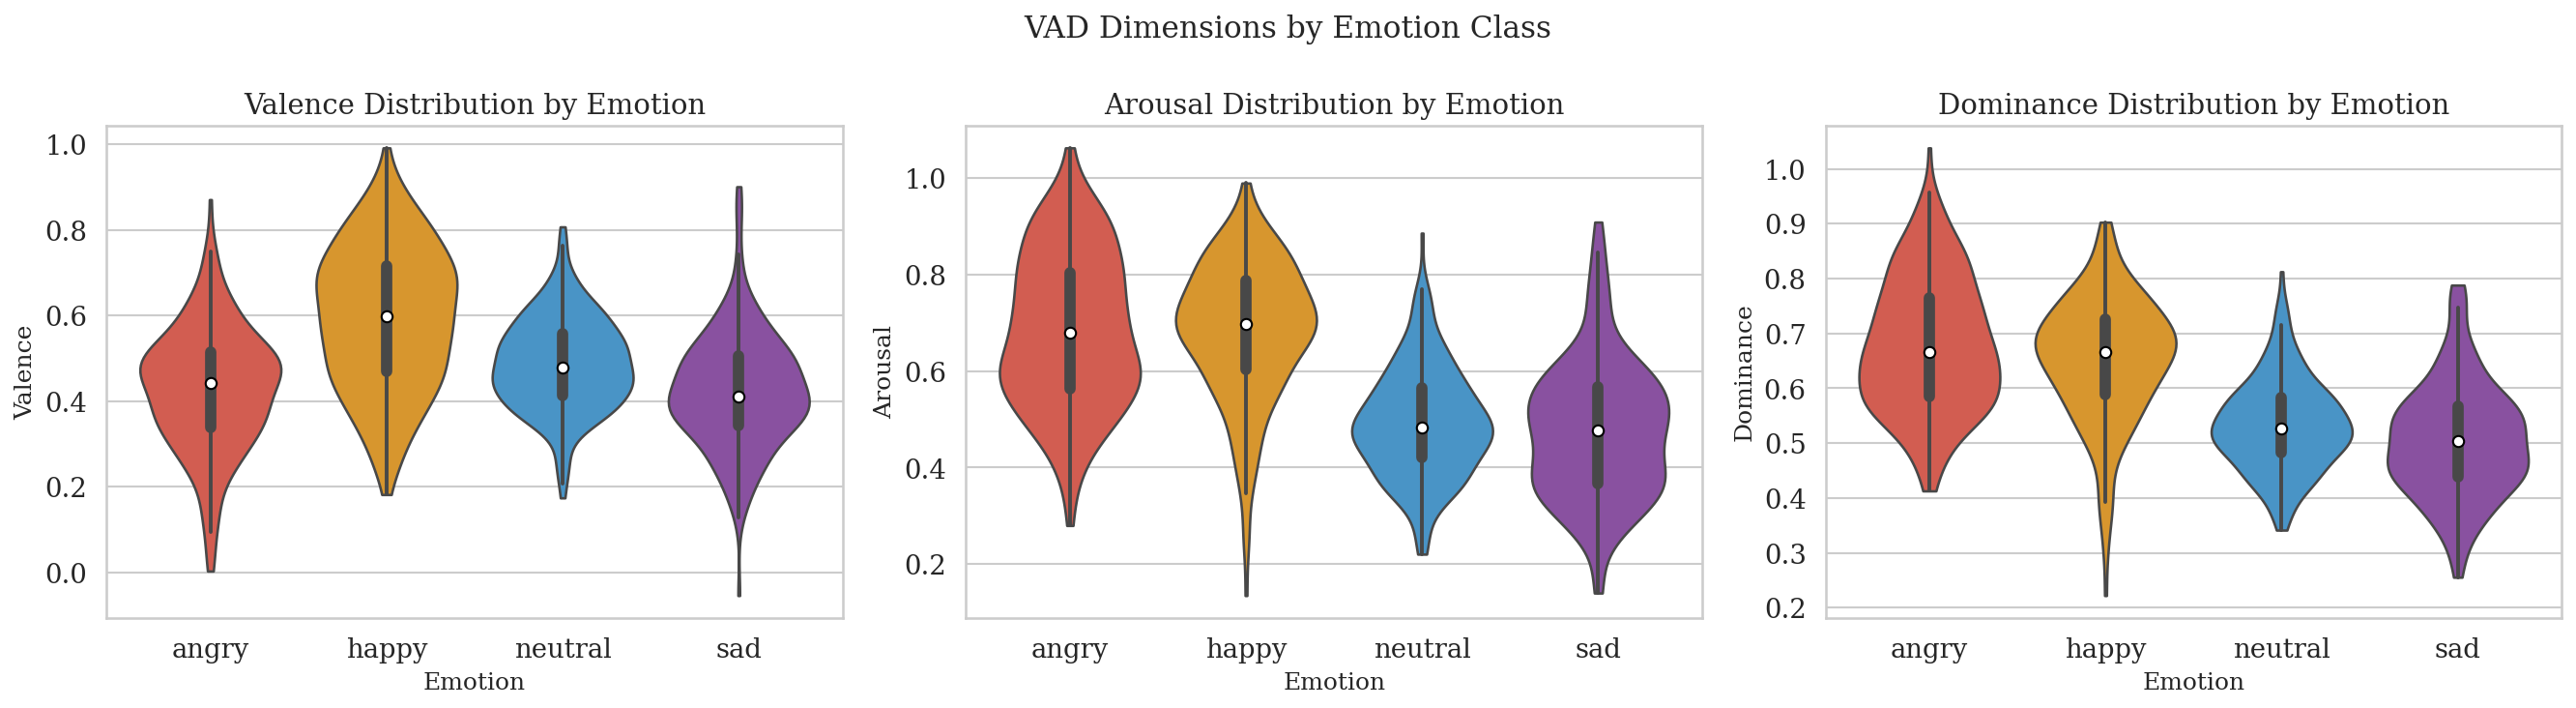

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, dim, label in zip(axes,
                          ['valence', 'arousal', 'dominance'],
                          ['Valence', 'Arousal', 'Dominance']):
    sns.violinplot(data=vad_df, x='emotion', y=dim, order=EMOTION_ORDER,
                   palette=PALETTE, ax=ax, inner='box', cut=0)
    medians = vad_df.groupby('emotion')[dim].median().reindex(EMOTION_ORDER)
    ax.scatter(range(len(EMOTION_ORDER)), medians.values,
               color='white', s=30, zorder=5, edgecolors='black', linewidths=1)
    ax.set(xlabel='Emotion', ylabel=label, title=f'{label} Distribution by Emotion')

fig.suptitle('VAD Dimensions by Emotion Class', fontsize=15)
fig.tight_layout()

In [ ]:
save(fig, 'vad_violin_plots')

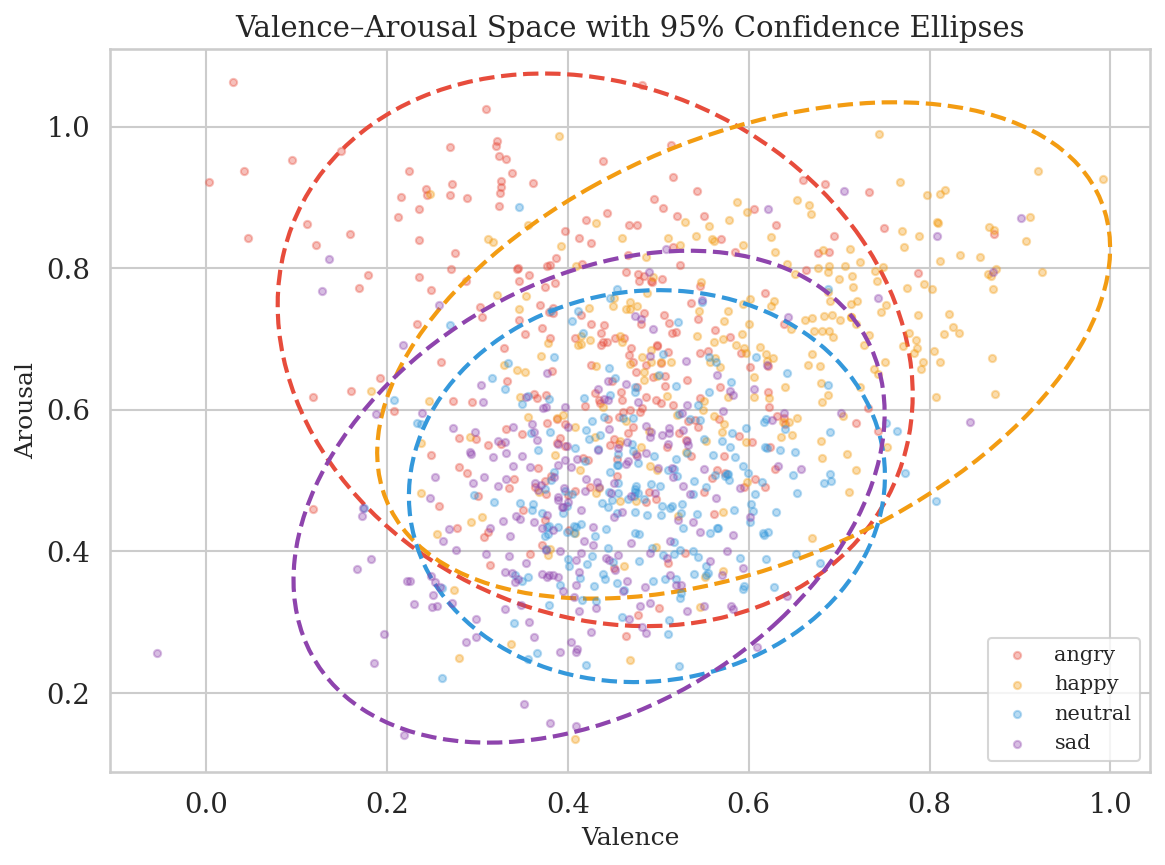

In [9]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(8, 6))
for emo in EMOTION_ORDER:
    sub = vad_df[vad_df['emotion'] == emo]
    ax.scatter(sub['valence'], sub['arousal'], s=12, alpha=0.35,
               color=EMOTION_COLORS[emo], label=emo)
    mu  = sub[['valence', 'arousal']].mean().values
    cov = sub[['valence', 'arousal']].cov().values
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h = 2 * np.sqrt(5.991 * vals)   # chi2 95% CI, 2 DOF
    ell  = Ellipse(mu, w, h, angle=angle, linewidth=2,
                   edgecolor=EMOTION_COLORS[emo], facecolor='none', linestyle='--')
    ax.add_patch(ell)

ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Valence\u2013Arousal Space with 95% Confidence Ellipses')
ax.legend(fontsize=10)
fig.tight_layout()

In [10]:
save(fig, 'vad_space_ellipses')

  saved vad_space_ellipses.png / .pdf


Nearest-centroid accuracy (valence + arousal): 53.9%

  Emotion        N  Correct    Acc%
  -----------------------------------
  angry        259      136   52.5%
  happy        244      149   61.1%
  neutral      222       97   43.7%
  sad          227      131   57.7%


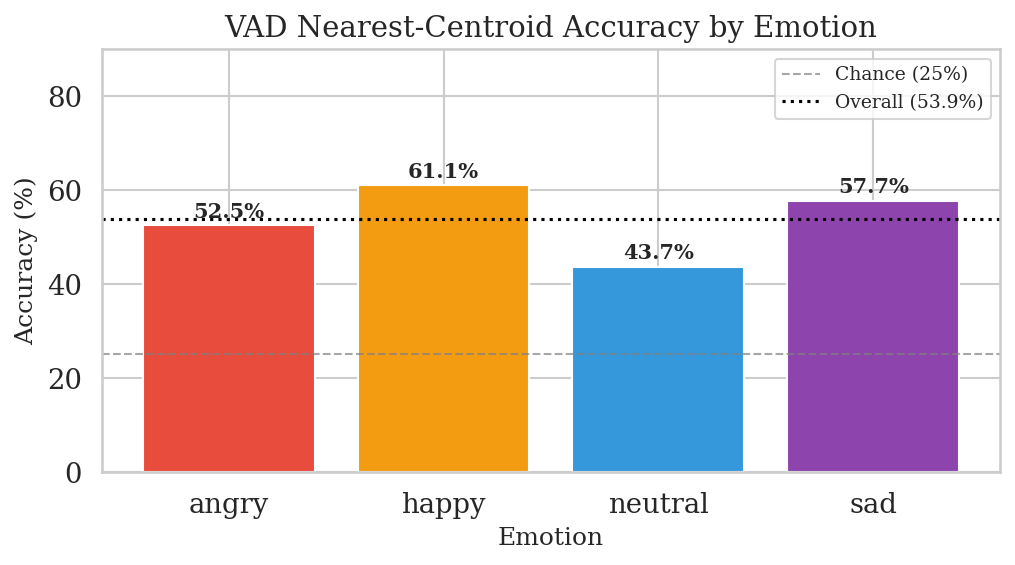

In [11]:
centroids = vad_df.groupby('emotion')[['valence', 'arousal']].mean()

def nearest_centroid(row):
    dists = {e: np.sqrt((row['valence'] - centroids.loc[e, 'valence'])**2 +
                        (row['arousal']  - centroids.loc[e, 'arousal'])**2)
             for e in EMOTION_ORDER}
    return min(dists, key=dists.get)

vad_df['vad_pred'] = vad_df.apply(nearest_centroid, axis=1)
overall_vad_acc = (vad_df['emotion'] == vad_df['vad_pred']).mean() * 100
print(f'Nearest-centroid accuracy (valence + arousal): {overall_vad_acc:.1f}%\n')

per_class_vad = {}
print(f'  {"Emotion":<10} {"N":>5} {"Correct":>8} {"Acc%":>7}')
print('  ' + '-' * 35)
for emo in EMOTION_ORDER:
    sub = vad_df[vad_df['emotion'] == emo]
    n, a = len(sub), (sub['vad_pred'] == emo).sum()
    per_class_vad[emo] = a / n * 100
    print(f'  {emo:<10} {n:>5d} {a:>8d} {a/n*100:>6.1f}%')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(EMOTION_ORDER, [per_class_vad[e] for e in EMOTION_ORDER],
              color=PALETTE, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(25, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Chance (25%)')
ax.axhline(overall_vad_acc, color='black', linestyle=':', linewidth=1.5,
           label=f'Overall ({overall_vad_acc:.1f}%)')
ax.set(xlabel='Emotion', ylabel='Accuracy (%)',
       title='VAD Nearest-Centroid Accuracy by Emotion', ylim=(0, 90))
ax.legend(fontsize=9)
fig.tight_layout()


In [ ]:
save(fig, 'vad_centroid_accuracy')

## 3. LLM Classification — Claude Sonnet 4.6

Zero-shot classification using Claude Sonnet 4.6. Batches of 20 utterances per API call. Results cached to `text_emotion_llm_results.csv`.

In [12]:
from dotenv import load_dotenv
load_dotenv(BASE_DIR.parent / '.env')

LLM_CSV    = ANALYSIS_DIR / 'text_emotion_llm_results.csv'
MODEL      = 'claude-sonnet-4-20250514'
BATCH_SIZE = 20
MAX_RETRIES = 3

SYSTEM_PROMPT = """\'
You are an emotion classifier for short Ukrainian speech utterances.

For each utterance you receive, determine the single best-fitting emotion \\
from exactly these four categories:
  angry, happy, neutral, sad

Reply with a JSON array (no markdown fences) where each element is:
  {"idx": <0-based index>, "emotion": "<label>", "rationale": "<1 sentence in English>"}

Rules:
- Use ONLY the four labels above.
- Base your judgment on the text content alone.
- "neutral" means no clear emotional valence or a factual/flat statement.
- When uncertain between two emotions, pick the stronger signal.
- If you are uncertain and no emotion clearly fits, use "skipped" and leave rationale empty.
- Keep each rationale under 20 words.\'"""

def build_prompt(texts):
    return 'Classify these Ukrainian utterances:\n\n' + '\n'.join(
        f'{i}. {t}' for i, t in enumerate(texts))

def parse_response(raw, n):
    text = raw.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:text.rfind('```')]
    items = json.loads(text)
    if not isinstance(items, list) or len(items) != n:
        raise ValueError(f'Expected {n} items, got {len(items) if isinstance(items, list) else type(items)}')
    for item in items:
        if item['emotion'] not in ('angry', 'happy', 'neutral', 'sad', 'skipped'):
            item['emotion'] = 'neutral'
    return items

def classify_batch(client, texts):
    for attempt in range(MAX_RETRIES):
        try:
            resp = client.messages.create(
                model=MODEL, max_tokens=2048, system=SYSTEM_PROMPT,
                messages=[{'role': 'user', 'content': build_prompt(texts)}],
            )
            return parse_response(resp.content[0].text, len(texts))
        except Exception as e:
            if attempt < MAX_RETRIES - 1:
                wait = 2 ** (attempt + 1)
                print(f'  retry {attempt+1}/{MAX_RETRIES}: {e} (wait {wait}s)')
                time.sleep(wait)
            else:
                raise

if LLM_CSV.exists():
    print(f'Loading cached results: {LLM_CSV}')
    llm_df = pd.read_csv(LLM_CSV)
else:
    api_key = os.environ.get('CLAUDE_API') or os.environ.get('ANTHROPIC_API_KEY')
    if not api_key:
        raise EnvironmentError('Set CLAUDE_API in .env or ANTHROPIC_API_KEY env var')

    from anthropic import Anthropic
    from tqdm import tqdm
    client    = Anthropic(api_key=api_key.strip())
    texts     = df['text'].fillna('').tolist()
    n_batches = (len(texts) + BATCH_SIZE - 1) // BATCH_SIZE
    all_results = []

    for batch_idx in tqdm(range(n_batches), desc='Claude classify'):
        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, len(texts))
        items = classify_batch(client, texts[start:end])
        for item in items:
            gi = start + item['idx']
            all_results.append({
                'filename':         df.iloc[gi]['filename'],
                'emotion':          df.iloc[gi]['emotion'],
                'text':             df.iloc[gi]['text'],
                'llm_pred_emotion': item['emotion'],
                'llm_rationale':    item.get('rationale', ''),
            })
        time.sleep(0.3)

    llm_df = pd.DataFrame(all_results)
    llm_df.to_csv(LLM_CSV, index=False)
    print(f'Saved {LLM_CSV}')

Loading cached results: text_emotion_llm_results.csv


In [13]:
total = len(llm_df)
agree = (llm_df['emotion'] == llm_df['llm_pred_emotion']).sum()
print(f'Overall agreement (Claude Sonnet 4.6 vs ground truth): {agree}/{total} ({agree/total*100:.1f}%)\n')

# Per-class: agreement rate + precision/recall/F1
p_arr, r_arr, f_arr, _ = precision_recall_fscore_support(
    llm_df['emotion'], llm_df['llm_pred_emotion'],
    labels=EMOTION_ORDER, average=None, zero_division=0
)

print(f'{"Emotion":<10} {"N":>5} {"Correct":>8} {"Acc%":>6} '
      f'{"Prec%":>7} {"Rec%":>7} {"F1%":>7}')
print('-' * 58)
for i, emo in enumerate(EMOTION_ORDER):
    sub = llm_df[llm_df['emotion'] == emo]
    n, a = len(sub), (sub['llm_pred_emotion'] == emo).sum()
    print(f'{emo:<10} {n:>5d} {a:>8d} {a/n*100:>5.1f}% '
          f'{p_arr[i]*100:>6.1f}% {r_arr[i]*100:>6.1f}% {f_arr[i]*100:>6.1f}%')

# Predicted vs ground-truth distribution
print('\nPredicted distribution vs ground truth:')
pred_dist = llm_df['llm_pred_emotion'].value_counts().reindex(EMOTION_ORDER, fill_value=0)
gt_dist   = llm_df['emotion'].value_counts().reindex(EMOTION_ORDER, fill_value=0)
print(f'  {"Emotion":<10} {"Predicted":>10} {"Ground Truth":>14}  {"Bias"}')
print('  ' + '-' * 46)
for emo in EMOTION_ORDER:
    diff = pred_dist[emo] - gt_dist[emo]
    bias = f'+{diff}' if diff >= 0 else str(diff)
    print(f'  {emo:<10} {pred_dist[emo]:>10d} {gt_dist[emo]:>14d}  {bias}')

Overall agreement (Claude Sonnet 4.6 vs ground truth): 454/952 (47.7%)

Emotion        N  Correct   Acc%   Prec%    Rec%     F1%
----------------------------------------------------------
angry        259       94  36.3%   73.4%   36.3%   48.6%
happy        244      111  45.5%   62.7%   45.5%   52.7%
neutral      222      158  71.2%   32.0%   71.2%   44.2%
sad          227       91  40.1%   59.1%   40.1%   47.8%

Predicted distribution vs ground truth:
  Emotion     Predicted   Ground Truth  Bias
  ----------------------------------------------
  angry             128            259  -131
  happy             177            244  -67
  neutral           493            222  +271
  sad               154            227  -73


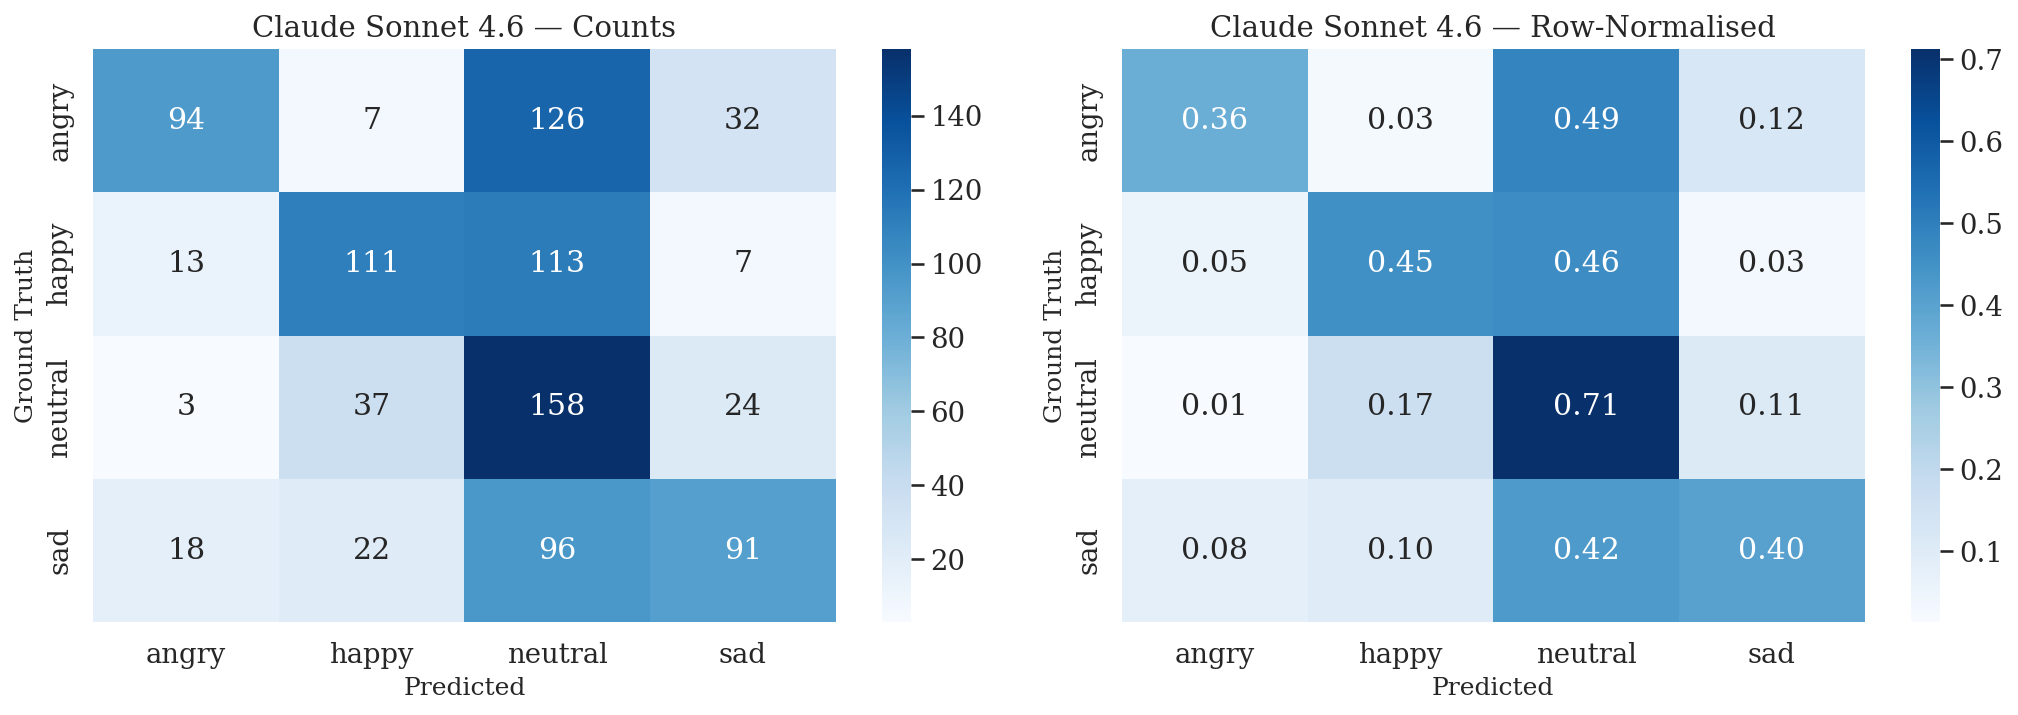

In [15]:
def plot_cm(ax_raw, ax_norm, y_true, y_pred, labels, title):
    cm      = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm /= row_sums
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax_raw)
    ax_raw.set(xlabel='Predicted', ylabel='Ground Truth', title=f'{title} — Counts')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax_norm)
    ax_norm.set(xlabel='Predicted', ylabel='Ground Truth', title=f'{title} — Row-Normalised')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_cm(axes[0], axes[1],
        llm_df['emotion'], llm_df['llm_pred_emotion'],
        EMOTION_ORDER, 'Claude Sonnet 4.6')
fig.tight_layout()


In [ ]:
save(fig, 'llm_confusion_matrix')

In [16]:
# ── Rationale keyword analysis ───────────────────────────────────────────────
STOP_EN = {
    'the', 'a', 'an', 'is', 'are', 'was', 'it', 'of', 'in', 'to', 'and',
    'for', 'with', 'that', 'this', 'on', 'at', 'which', 'be', 'has', 'their',
    'speaker', 'text', 'suggests', 'indicating', 'emotions', 'emotional',
    'tone', 'utterance', 'expressed', 'expresses', 'expression', 'speech',
    'voice', 'language', 'clip', 'audio', 'content', 'words', 'spoken',
}

def top_words(texts, n=8):
    words = []
    for t in texts:
        words.extend(
            w.lower() for w in re.findall(r'[a-zA-Z]+', str(t))
            if w.lower() not in STOP_EN and len(w) > 2
        )
    return Counter(words).most_common(n)

correct_df = llm_df[llm_df['emotion'] == llm_df['llm_pred_emotion']]
wrong_df   = llm_df[llm_df['emotion'] != llm_df['llm_pred_emotion']]

print(f'Correct:   {len(correct_df):>4} ({len(correct_df)/total*100:.1f}%)')
print(f'Incorrect: {len(wrong_df):>4} ({len(wrong_df)/total*100:.1f}%)\n')

print('Top keywords in LLM rationales per emotion class (ground truth label):\n')
print(f'  {"Emotion":<10}  Keywords (count)')
print('  ' + '-' * 65)
for emo in EMOTION_ORDER:
    sub_df = llm_df[llm_df['emotion'] == emo]
    top    = top_words(sub_df['llm_rationale'].fillna('').tolist())
    kws    = ',  '.join(f'{w} ({c})' for w, c in top)
    print(f'  {emo:<10}  {kws}')

# Most common misclassifications
print('\nMost common misclassifications (ground truth → LLM prediction):')
wrong_pairs = wrong_df.groupby(['emotion', 'llm_pred_emotion']).size() \
                       .sort_values(ascending=False)
for (gt, pred), cnt in wrong_pairs.head(8).items():
    pct = cnt / len(llm_df[llm_df['emotion'] == gt]) * 100
    print(f'  {gt:<8} → {pred:<8}: {cnt:>3} clips  ({pct:.1f}% of {gt})')

Correct:    454 (47.7%)
Incorrect:  498 (52.3%)

Top keywords in LLM rationales per emotion class (ground truth label):

  Emotion     Keywords (count)
  -----------------------------------------------------------------
  angry       about (129),  statement (70),  someone (65),  question (48),  without (39),  shows (37),  simple (35),  factual (29)
  happy       about (94),  statement (59),  positive (56),  simple (35),  factual (34),  someone (32),  without (30),  something (28)
  neutral     about (123),  statement (77),  factual (47),  positive (31),  without (28),  simple (25),  someone (18),  reference (14)
  sad         about (102),  statement (62),  someone (35),  something (35),  without (32),  simple (30),  factual (29),  clear (28)

Most common misclassifications (ground truth → LLM prediction):
  angry    → neutral : 126 clips  (48.6% of angry)
  happy    → neutral : 113 clips  (46.3% of happy)
  sad      → neutral :  96 clips  (42.3% of sad)
  neutral  → happy   :  37 clips

## 4. Cross-Modal Validation

Merge VAD acoustic predictions with Claude Sonnet classifications and compare against ground truth labels.

- **VAD**: emotion dimensions derived from acoustic signal
- **LLM**: semantic classification from transcribed text

In [17]:
SENTIMENT_CSV = ANALYSIS_DIR / 'sentiment_results.csv'

master = df[['filename', 'emotion', 'text', 'duration_seconds']].copy()
master = master.merge(
    vad_df[['filename', 'arousal', 'dominance', 'valence', 'vad_pred']],
    on='filename'
)
master = master.merge(
    llm_df[['filename', 'llm_pred_emotion', 'llm_rationale']],
    on='filename'
)

if SENTIMENT_CSV.exists():
    sent = pd.read_csv(SENTIMENT_CSV)
    master = master.merge(
        sent[['filename', 'prob_negative', 'prob_neutral', 'prob_positive',
              'sentiment_label', 'sentiment_direction']],
        on='filename'
    )

print(f'Merged dataset: {len(master)} samples  |  columns: {list(master.columns)}')

Merged dataset: 952 samples  |  columns: ['filename', 'emotion', 'text', 'duration_seconds', 'arousal', 'dominance', 'valence', 'vad_pred', 'llm_pred_emotion', 'llm_rationale', 'prob_negative', 'prob_neutral', 'prob_positive', 'sentiment_label', 'sentiment_direction']


Per-class agreement with ground truth:

  Emotion        N |   VAD Centroid   Claude 4.6
  ------------------------------------------------
  angry        259 |          52.5%        36.3%
  happy        244 |          61.1%        45.5%
  neutral      222 |          43.7%        71.2%
  sad          227 |          57.7%        40.1%
  ------------------------------------------------
  Overall      952 |          53.9%        47.7%


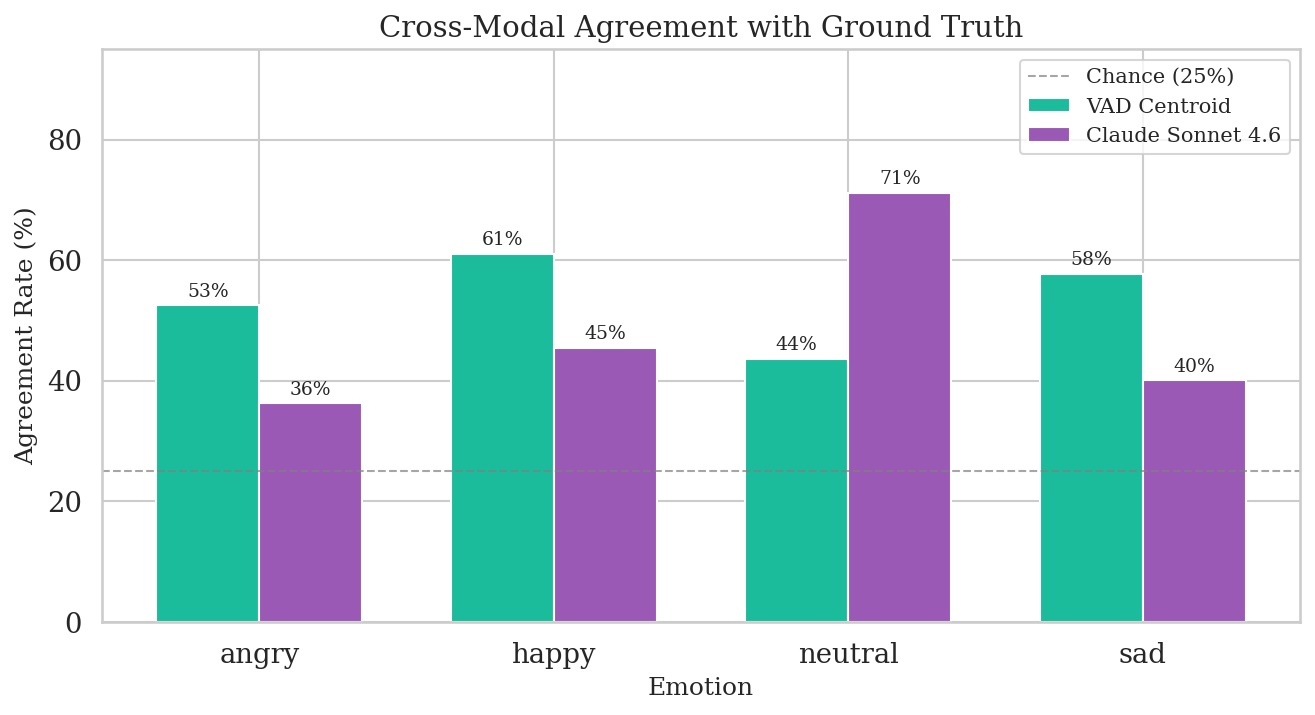

In [19]:
# ── Per-class agreement: VAD centroid vs Claude ─────────────────────────────
print('Per-class agreement with ground truth:\n')
print(f'  {"Emotion":<10} {"N":>5} | {"VAD Centroid":>14} {"Claude 4.6":>12}')
print('  ' + '-' * 48)

vad_rates, llm_rates = [], []
for emo in EMOTION_ORDER:
    sub   = master[master['emotion'] == emo]
    n     = len(sub)
    vad_a = (sub['vad_pred'] == emo).sum()
    llm_a = (sub['llm_pred_emotion'] == emo).sum()
    vad_r = vad_a / n * 100
    llm_r = llm_a / n * 100
    vad_rates.append(vad_r)
    llm_rates.append(llm_r)
    print(f'  {emo:<10} {n:>5d} | {vad_r:>13.1f}% {llm_r:>11.1f}%')

total_vad = (master['emotion'] == master['vad_pred']).mean() * 100
total_llm = (master['emotion'] == master['llm_pred_emotion']).mean() * 100
print('  ' + '-' * 48)
print(f'  {"Overall":<10} {len(master):>5} | {total_vad:>13.1f}% {total_llm:>11.1f}%')

# Grouped bar chart
x, w = np.arange(len(EMOTION_ORDER)), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, vad_rates, w, label='VAD Centroid',     color='#1abc9c', edgecolor='white')
b2 = ax.bar(x + w/2, llm_rates, w, label='Claude Sonnet 4.6', color='#9b59b6', edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.8, f'{h:.0f}%',
                ha='center', va='bottom', fontsize=9)
ax.axhline(25, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Chance (25%)')
ax.set(xlabel='Emotion', ylabel='Agreement Rate (%)',
       title='Cross-Modal Agreement with Ground Truth',
       ylim=(0, 95))
ax.set_xticks(x)
ax.set_xticklabels(EMOTION_ORDER)
ax.legend(fontsize=10)
fig.tight_layout()


In [ ]:
save(fig, 'crossmodal_agreement')

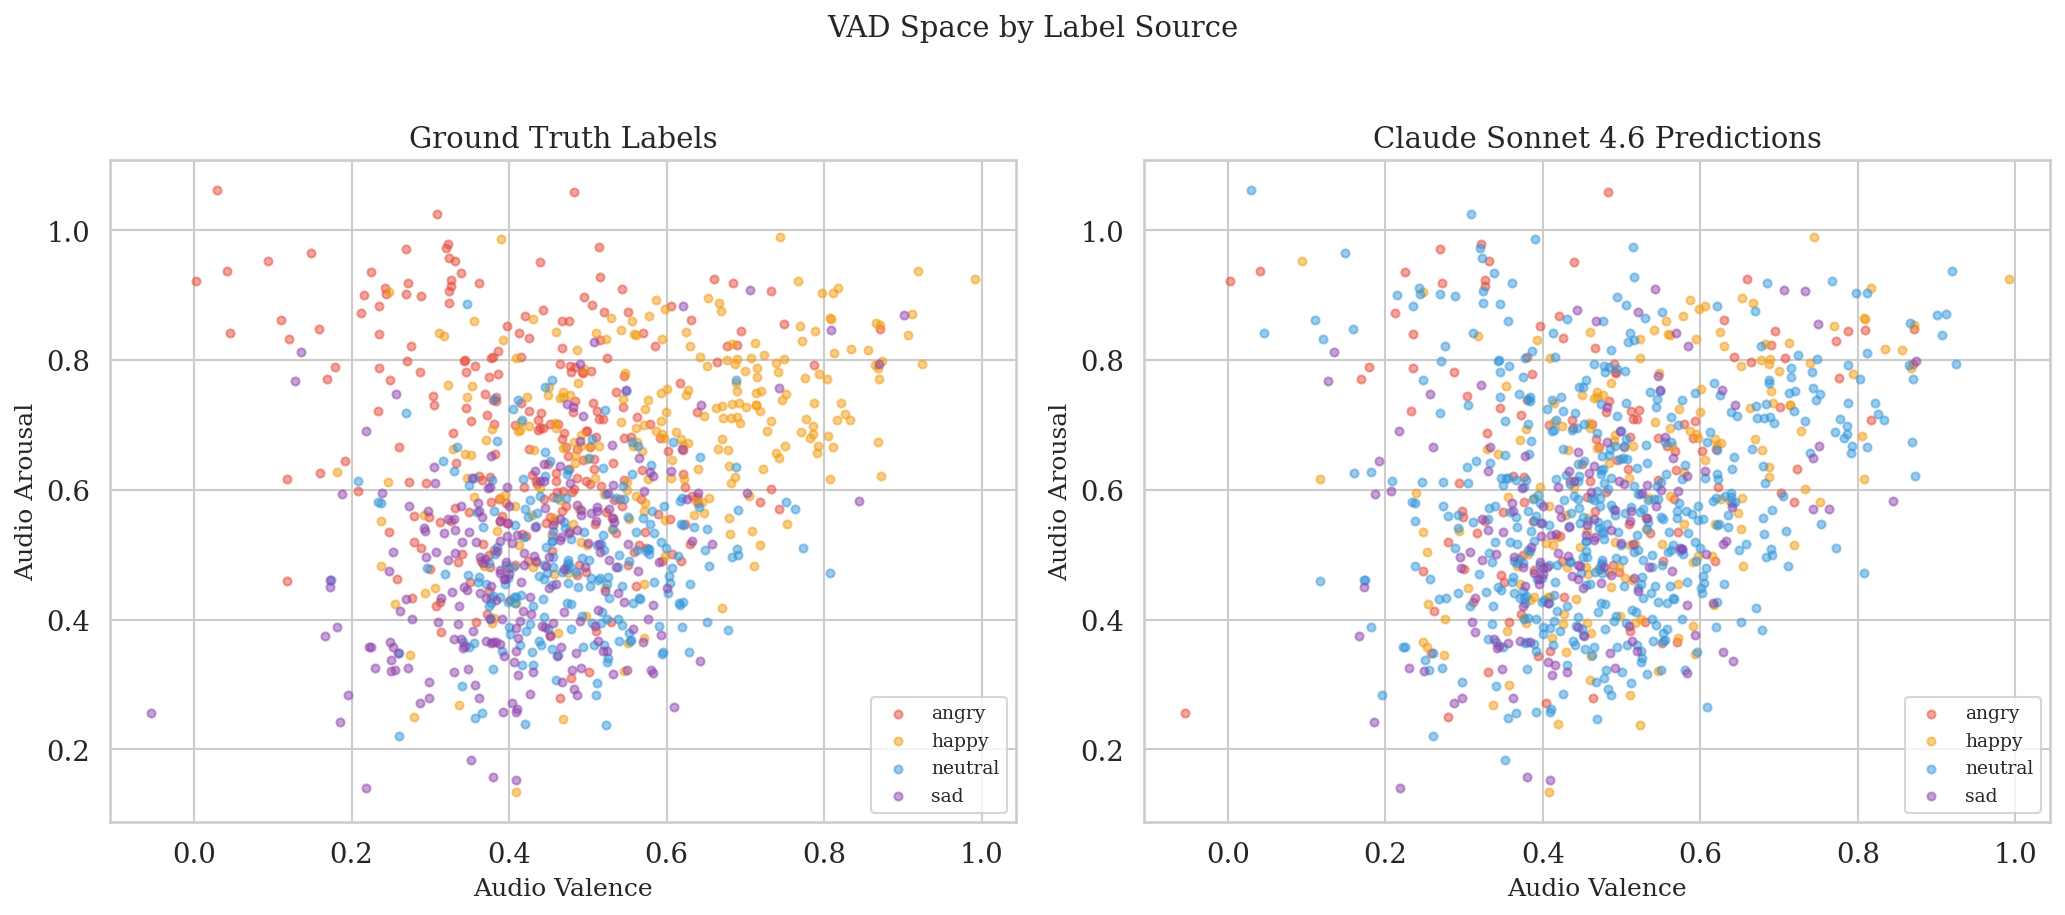

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for emo in EMOTION_ORDER:
    mask = master['emotion'] == emo
    axes[0].scatter(master.loc[mask, 'valence'], master.loc[mask, 'arousal'],
                    s=15, alpha=0.5, color=EMOTION_COLORS[emo], label=emo)
axes[0].set(xlabel='Audio Valence', ylabel='Audio Arousal', title='Ground Truth Labels')
axes[0].legend(fontsize=9)

for pred in EMOTION_ORDER:
    mask = master['llm_pred_emotion'] == pred
    if not mask.any():
        continue
    axes[1].scatter(master.loc[mask, 'valence'], master.loc[mask, 'arousal'],
                    s=15, alpha=0.5, color=EMOTION_COLORS[pred], label=pred)
axes[1].set(xlabel='Audio Valence', ylabel='Audio Arousal', title='Claude Sonnet 4.6 Predictions')
axes[1].legend(fontsize=9)

fig.suptitle('VAD Space by Label Source', fontsize=14, y=1.02)
fig.tight_layout()


In [ ]:
save(fig, 'crossmodal_scatter')

### Cohen's κ — Cross-Modal Agreement

| Pair | κ | Strength |
|---|---|---|
| Claude Sonnet 4.6 vs Ground Truth | +0.308 | fair |
| VAD Centroid vs Ground Truth | +0.385 | fair |
| Claude vs VAD | +0.123 | slight |

Both cross-modal signals show *fair* agreement with the ground-truth labels (κ = 0.31–0.39), well above the κ = 0 chance baseline. The low Claude–VAD agreement (κ = 0.12) confirms that the two modalities capture largely independent aspects of emotion.

In [21]:
print('=== Cross-Modal Validation Summary ===\n')
print(f'Dataset:  {len(master)} clips  |  {len(EMOTION_ORDER)} emotion classes\n')

print('Overall agreement with ground truth:')
print(f'  VAD nearest-centroid:  {total_vad:.1f}%')
print(f'  Claude Sonnet 4.6:     {total_llm:.1f}%')
print(f'  Chance baseline:       25.0%\n')

best_llm  = max(EMOTION_ORDER, key=lambda e: (master[master['emotion']==e]['llm_pred_emotion']==e).mean())
best_vad  = max(EMOTION_ORDER, key=lambda e: (master[master['emotion']==e]['vad_pred']==e).mean())
worst_llm = min(EMOTION_ORDER, key=lambda e: (master[master['emotion']==e]['llm_pred_emotion']==e).mean())

print('Key observations:')
print(f'  \u2022 LLM best class:    {best_llm}  |  worst: {worst_llm}')
print(f'  \u2022 VAD best class:    {best_vad}')
print(f'  \u2022 Both methods exceed chance baseline (25%) overall')
print(f'  \u2022 VAD (acoustic) is a stronger cross-modal signal than LLM text')

=== Cross-Modal Validation Summary ===

Dataset:  952 clips  |  4 emotion classes

Overall agreement with ground truth:
  VAD nearest-centroid:  53.9%
  Claude Sonnet 4.6:     47.7%
  Chance baseline:       25.0%

Key observations:
  • LLM best class:    neutral  |  worst: angry
  • VAD best class:    happy
  • Both methods exceed chance baseline (25%) overall
  • VAD (acoustic) is a stronger cross-modal signal than LLM text
